In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "true"

!pip -q install --upgrade pip
!pip -q install --upgrade transformers==4.44.2 datasets==2.19.1 accelerate==0.34.2 evaluate==0.4.2   scikit-learn==1.5.1 matplotlib==3.9.0 sentencepiece==0.2.0   openpyxl==3.1.5

import torch, platform
print("Torch:", torch.__version__, "| CUDA:", torch.version.cuda if torch.cuda.is_available() else None)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.1 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
Torch: 2.8.0+cu126 | CUDA: 12.6
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
from dataclasses import dataclass
from typing import Optional

MODEL_NAME = "BSC-LT/salamandra-7b-instruct"   #@param {type:"string"}
PROJECT_NAME = "salamandra_swe_cls"            #@param {type:"string"}
OUTPUT_DIR = f"/{PROJECT_NAME}"        #@param {type:"string"}

DATA_XLSX = "radiologue dataset.xlsx"  #@param {type:"string"}
SHEET_NAME = 0  #@param ["0"] {allow-input: true}
TEXT_COL = "Summa"         #@param {type:"string"}
LABEL_COL = "End Result"   #@param {type:"string"}

MIN_SAMPLES_PER_LABEL = 50  #@param {type:"number"}

VAL_SIZE  = 0.15  #@param {type:"number"}
TEST_SIZE = 0.15  #@param {type:"number"}
SEED = 42         #@param {type:"number"}
EPOCHS = 3                           #@param {type:"number"}
LR = 1e-5                             #@param {type:"number"}
WEIGHT_DECAY = 0.05                   #@param {type:"number"}
WARMUP_RATIO = 0.05                   #@param {type:"number"}
MAX_LENGTH = 768                      #@param {type:"number"}
PER_DEVICE_TRAIN_BATCH_SIZE = 2       #@param {type:"number"}
PER_DEVICE_EVAL_BATCH_SIZE = 2        #@param {type:"number"}
GRAD_ACCUM = 8                        #@param {type:"number"}
BF16 = True
FP16 = False
GRADIENT_CHECKPOINTING = True
USE_FUSED_OPTIMIZER = True

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("OUTPUT_DIR:", OUTPUT_DIR)


OUTPUT_DIR: /salamandra_swe_cls


In [ ]:
from google.colab import files
import io, pandas as pd

if not DATA_XLSX:
    print("Select your Excel (.xlsx) file to upload...")
    uploaded = files.upload()
    if uploaded:
        fname = next(iter(uploaded.keys()))
        DATA_XLSX = f"/content/{fname}"
        with open(DATA_XLSX, "wb") as f:
            f.write(uploaded[fname])
        print("Uploaded to:", DATA_XLSX)
else:
    print("DATA_XLSX already set:", DATA_XLSX)


DATA_XLSX already set: radiologue dataset.xlsx


Columns: ['Summa', 'End Result']
Unique labels: 33
End Result
B3                 279
L5                  82
B2                  76
N1                  76
A1                  69
L7                  69
N14                 67
A4                  65
N4                  63
A4 med sen fas      62
A3                  62
B10                 56
P2                  55
BBA1                54
N6                  44
N10                 37
N5                  37
A10                 34
N8                  23
A11 med sen fas     12
Name: count, dtype: int64
Kept 14 labels with ≥ 50 samples. Total rows: 1135
Filtered dataset saved to: /salamandra_swe_cls/filtered_dataset.csv


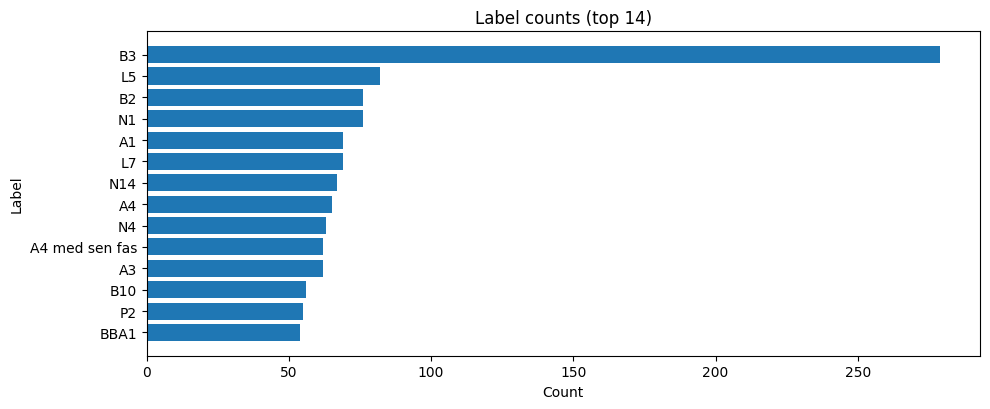

In [ ]:

import pandas as pd
import numpy as np

if not DATA_XLSX:
    raise ValueError("DATA_XLSX is empty. Mount or upload your Excel file, set DATA_XLSX, then re-run.")

df = pd.read_excel(DATA_XLSX, sheet_name=SHEET_NAME)
print("Columns:", df.columns.tolist())

if TEXT_COL not in df.columns or LABEL_COL not in df.columns:
    raise ValueError(f"Expected columns '{TEXT_COL}' and '{LABEL_COL}'. Found: {df.columns.tolist()}")

df = df[[TEXT_COL, LABEL_COL]].copy()
df.dropna(inplace=True)
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()

counts = df[LABEL_COL].value_counts().sort_values(ascending=False)
print("Unique labels:", counts.shape[0])
print(counts.head(20))

keep = counts[counts >= MIN_SAMPLES_PER_LABEL].index
filtered_df = df[df[LABEL_COL].isin(keep)].reset_index(drop=True)
print(f"Kept {filtered_df[LABEL_COL].nunique()} labels with ≥ {MIN_SAMPLES_PER_LABEL} samples. Total rows: {len(filtered_df)}")

filtered_path = f"{OUTPUT_DIR}/filtered_dataset.csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)
filtered_df.to_csv(filtered_path, index=False)
print("Filtered dataset saved to:", filtered_path)

topN = min(30, len(keep))
if topN > 0:
    import matplotlib.pyplot as plt
    top_counts = counts.loc[keep].head(topN)
    plt.figure(figsize=(10, max(4, 0.3*topN)))
    plt.barh(top_counts.index[::-1], top_counts.values[::-1])
    plt.title(f"Label counts (top {topN})")
    plt.xlabel("Count")
    plt.ylabel("Label")
    plt.tight_layout()
    plt.show()


## 🔀 Stratified Train/Val/Test Split

In [ ]:

from sklearn.model_selection import train_test_split

if filtered_df[LABEL_COL].nunique() < 2:
    raise ValueError("Not enough labels after filtering. Reduce MIN_SAMPLES_PER_LABEL or verify data.")

train_df, tmp_df = train_test_split(
    filtered_df, test_size=VAL_SIZE + TEST_SIZE, random_state=SEED, stratify=filtered_df[LABEL_COL]
)

rel_val = VAL_SIZE / (VAL_SIZE + TEST_SIZE) if (VAL_SIZE + TEST_SIZE) > 0 else 0.0
if (VAL_SIZE + TEST_SIZE) > 0:
    val_df, test_df = train_test_split(
        tmp_df, test_size=(1 - rel_val), random_state=SEED, stratify=tmp_df[LABEL_COL]
    )
else:
    val_df, test_df = pd.DataFrame(columns=filtered_df.columns), pd.DataFrame(columns=filtered_df.columns)

print(f"Train: {len(train_df)}   Val: {len(val_df)}   Test: {len(test_df)}")


Train: 794   Val: 170   Test: 171


In [ ]:

labels = sorted(filtered_df[LABEL_COL].unique().tolist())
label2id = {lbl:i for i,lbl in enumerate(labels)}
id2label = {i:lbl for lbl,i in label2id.items()}
num_labels = len(labels)

print("num_labels:", num_labels)
print("Sample labels:", labels[:10], "..." if len(labels) > 10 else "")


num_labels: 14
Sample labels: ['A1', 'A3', 'A4', 'A4 med sen fas', 'B10', 'B2', 'B3', 'BBA1', 'L5', 'L7'] ...


In [ ]:
from huggingface_hub import login

hf_token = ""
login(hf_token)

In [ ]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

def build_prompt(text: str) -> str:
    return f"""Du är en radiologisk assistent. Läs klinisk information på svenska och välj rätt undersökningsprotokoll från etikettlistan som modellen har tränats på.
Klinisk information:
{text}
Svara ENDAST med etiketten (protokollnamnet)."""

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True)) if len(val_df) else None
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True)) if len(test_df) else None

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tok(batch, max_len: int):
    texts = [build_prompt(t) for t in batch[TEXT_COL]]
    out = tokenizer(texts, max_length=max_len, padding="max_length", truncation=True)
    out["labels"] = [label2id[x] for x in batch[LABEL_COL]]
    return out

def retokenize(ds_dict, max_len: int):
    keep_cols = [TEXT_COL, LABEL_COL]
    out = {}
    out["train"] = train_ds.map(lambda b: tok(b, max_len), batched=True, remove_columns=[c for c in train_ds.column_names if c not in keep_cols])
    if val_ds is not None:
        out["validation"] = val_ds.map(lambda b: tok(b, max_len), batched=True, remove_columns=[c for c in val_ds.column_names if c not in keep_cols])
    if test_ds is not None:
        out["test"] = test_ds.map(lambda b: tok(b, max_len), batched=True, remove_columns=[c for c in test_ds.column_names if c not in keep_cols])
    return DatasetDict(out)

ds = retokenize(None, MAX_LENGTH)
print(ds)

Map:   0%|          | 0/794 [00:00<?, ? examples/s]

Map:   0%|          | 0/170 [00:00<?, ? examples/s]

Map:   0%|          | 0/171 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Summa', 'End Result', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 794
    })
    validation: Dataset({
        features: ['Summa', 'End Result', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 170
    })
    test: Dataset({
        features: ['Summa', 'End Result', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 171
    })
})


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    torch_dtype=torch.bfloat16 if BF16 else None,
    device_map="auto",
    trust_remote_code=True,
    id2label=id2label,
    label2id=label2id,
)
if GRADIENT_CHECKPOINTING:
    model.gradient_checkpointing_enable()

print("Loaded:", MODEL_NAME)


config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.46G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/2.10G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at BSC-LT/salamandra-7b-instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded: BSC-LT/salamandra-7b-instruct


In [ ]:
import evaluate, numpy as np
from sklearn.metrics import accuracy_score, f1_score

def top_k_acc(logits, labels, k=3):
    if logits.ndim == 2:
        topk = np.argsort(-logits, axis=1)[:, :k]
        correct = sum(1 for i in range(len(labels)) if labels[i] in topk[i])
        return correct / len(labels) if len(labels) else 0.0
    return 0.0

def compute_metrics(eval_pred):
    logits, labels_np = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels_np, preds)
    f1m = f1_score(labels_np, preds, average="macro")
    f1w = f1_score(labels_np, preds, average="weighted")
    t3 = top_k_acc(logits, labels_np, k=3)
    return {"accuracy": acc, "f1_macro": f1m, "f1_weighted": f1w, "top3_acc": t3}

In [ ]:
from transformers import TrainingArguments, Trainer
import torch, math, gc

if getattr(model.config, "pad_token_id", None) is None:
    model.config.pad_token_id = tokenizer.pad_token_id or tokenizer.eos_token_id
print("✅ pad_token_id set to:", model.config.pad_token_id)

attempts = [
    {"max_len": MAX_LENGTH, "train_bs": PER_DEVICE_TRAIN_BATCH_SIZE, "eval_bs": PER_DEVICE_EVAL_BATCH_SIZE, "accum": GRAD_ACCUM},
    {"max_len": 640, "train_bs": 2, "eval_bs": 2, "accum": max(GRAD_ACCUM, 10)},
    {"max_len": 512, "train_bs": 1, "eval_bs": 1, "accum": max(GRAD_ACCUM, 16)},
    {"max_len": 384, "train_bs": 1, "eval_bs": 1, "accum": max(GRAD_ACCUM, 24)},
]

best_metrics = None
last_err = None

for i, cfg in enumerate(attempts, start=1):
    try:
        print(f"\n=== Attempt {i}/{len(attempts)}: max_len={cfg['max_len']}, bs={cfg['train_bs']}, accum={cfg['accum']} ===")

        ds = retokenize(ds, cfg["max_len"])

        optim = "adamw_torch_fused" if USE_FUSED_OPTIMIZER else "adamw_torch"

        args = TrainingArguments(
            output_dir=OUTPUT_DIR,
            num_train_epochs=EPOCHS,
            per_device_train_batch_size=cfg["train_bs"],
            per_device_eval_batch_size=cfg["eval_bs"],
            gradient_accumulation_steps=cfg["accum"],
            learning_rate=LR,
            weight_decay=WEIGHT_DECAY,
            warmup_ratio=WARMUP_RATIO,
            lr_scheduler_type="cosine",
            logging_steps=25,
            evaluation_strategy="epoch" if "validation" in ds else "no",
            save_strategy="epoch",
            load_best_model_at_end=("validation" in ds),
            metric_for_best_model="f1_macro",
            greater_is_better=True,
            bf16=BF16,
            fp16=FP16,
            gradient_checkpointing=GRADIENT_CHECKPOINTING,
            dataloader_num_workers=2,
            report_to="none",
            optim=optim,
            max_grad_norm=1.0,
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=ds["train"],
            eval_dataset=ds["validation"] if "validation" in ds else None,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics if "validation" in ds else None,
        )

        print("🚀 Starting training ...")
        train_out = trainer.train()
        print("✅ Training finished successfully.")

        if "validation" in ds:
            best_metrics = trainer.evaluate()
            print("📊 Validation metrics:", best_metrics)
        break

    except RuntimeError as e:
        last_err = e
        if "out of memory" in str(e).lower():
            print("⚠️ CUDA OOM detected → Retrying with smaller setup ...")
            torch.cuda.empty_cache()
            gc.collect()
            torch.cuda.synchronize()
        else:
            raise e

if last_err and best_metrics is None:
    raise last_err


✅ pad_token_id set to: 2

=== Attempt 1/4: max_len=768, bs=2, accum=8 ===


Map:   0%|          | 0/794 [00:00<?, ? examples/s]

Map:   0%|          | 0/170 [00:00<?, ? examples/s]

Map:   0%|          | 0/171 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Top3 Acc
0,3.659600,1.519704,0.505882,0.418177,0.460254,0.800000
1,0.788000,0.352166,0.894118,0.894617,0.894046,0.994118
2,0.166200,0.289488,0.894118,0.892090,0.895312,1.000000


We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommend

✅ Training finished successfully.


📊 Validation metrics: {'eval_loss': 0.3521658778190613, 'eval_accuracy': 0.8941176470588236, 'eval_f1_macro': 0.8946173064149697, 'eval_f1_weighted': 0.8940459033221618, 'eval_top3_acc': 0.9941176470588236, 'eval_runtime': 9.2418, 'eval_samples_per_second': 18.395, 'eval_steps_per_second': 9.197, 'epoch': 2.9622166246851385}


Accuracy (Top-1): 0.8655
Top-3 Accuracy:   0.9649
F1 Macro:         0.8499
F1 Weighted:      0.8637

Classification Report:

                precision    recall  f1-score   support

            A1     0.8182    0.8182    0.8182        11
            A3     0.6364    0.7778    0.7000         9
            A4     0.8571    0.6667    0.7500         9
A4 med sen fas     0.9000    1.0000    0.9474         9
           B10     1.0000    0.7500    0.8571         8
            B2     1.0000    0.9167    0.9565        12
            B3     0.8367    0.9762    0.9011        42
          BBA1     1.0000    0.8750    0.9333         8
            L5     0.9231    0.9231    0.9231        13
            L7     0.8000    0.7273    0.7619        11
            N1     0.8571    1.0000    0.9231        12
           N14     1.0000    0.8000    0.8889        10
            N4     0.8750    0.7778    0.8235         9
            P2     0.8333    0.6250    0.7143         8

      accuracy                   

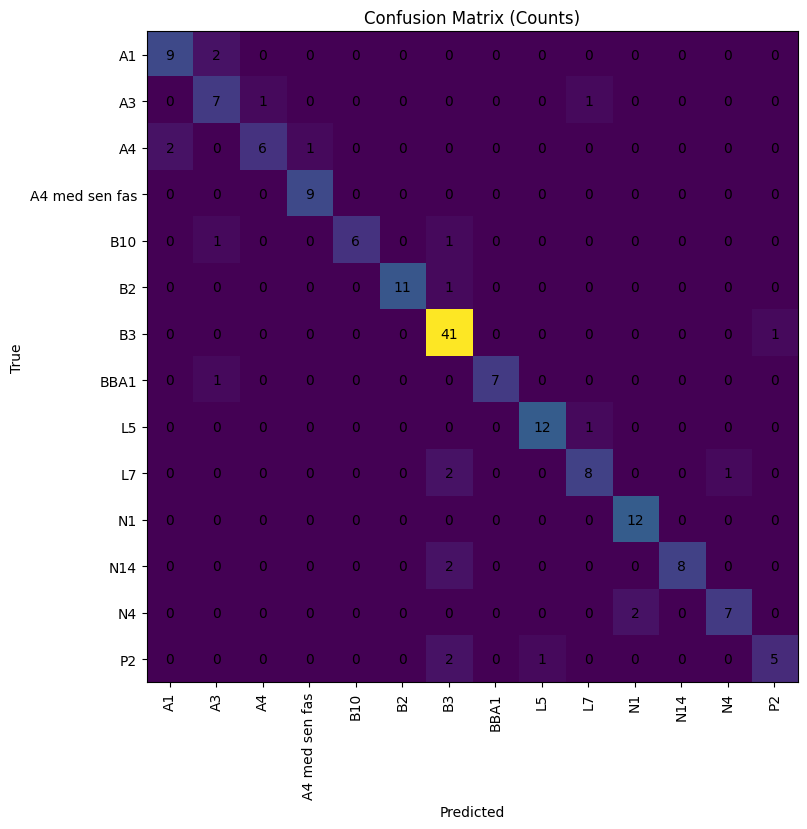

Saved: /salamandra_swe_cls/confusion_matrix.png


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

if "test" in ds and len(ds["test"]):
    eval_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
        bf16=BF16,
        fp16=FP16,
        report_to="none"
    )

    preds = Trainer(model=model, args=eval_args, tokenizer=tokenizer).predict(ds["test"])
    y_true = preds.label_ids
    logits = preds.predictions
    y_pred = np.argmax(logits, axis=-1)

    # ✅ Top-3 accuracy
    top3_preds = np.argsort(-logits, axis=1)[:, :3]
    top3_correct = sum([y_true[i] in top3_preds[i] for i in range(len(y_true))])
    top3_acc = top3_correct / len(y_true)

    # ✅ Metrics
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    print(f"Accuracy (Top-1): {acc:.4f}")
    print(f"Top-3 Accuracy:   {top3_acc:.4f}")
    print(f"F1 Macro:         {f1_macro:.4f}")
    print(f"F1 Weighted:      {f1_weighted:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(
        y_true,
        y_pred,
        target_names=[id2label[i] for i in range(num_labels)],
        digits=4
    ))

    # ✅ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_labels)))
    fig, ax = plt.subplots(figsize=(max(6, num_labels*0.6), max(5.5, num_labels*0.6)))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title("Confusion Matrix (Counts)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(num_labels))
    ax.set_yticks(range(num_labels))
    ax.set_xticklabels([id2label[i] for i in range(num_labels)], rotation=90)
    ax.set_yticklabels([id2label[i] for i in range(num_labels)])
    for i in range(num_labels):
        for j in range(num_labels):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
    plt.savefig(cm_path, bbox_inches="tight")
    plt.show()
    print("Saved:", cm_path)

else:
    print("No test set present. Skipping test evaluation.")


In [ ]:
from transformers import TextClassificationPipeline
import torch
import torch.nn.functional as F

pipe = TextClassificationPipeline(
    model=model, tokenizer=tokenizer, top_k=None
)

swedish_text = "Anamnes: Bästa kollegor! Man som gjort en TEVAR-behandling p.g.a. trauma. Tacksam för CT av aorta i thorax för stentkontroll. Frågeställning:"

def predict_top3_labels(text: str, k: int = 3):
    encoded = tokenizer(build_prompt(text), truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
    encoded = {k: v.to(model.device) for k, v in encoded.items()}
    with torch.no_grad():
        logits = model(**encoded).logits
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
    topk_idx = probs.argsort()[-k:][::-1]
    results = [(id2label[i], float(probs[i])) for i in topk_idx]
    return results

top3 = predict_top3_labels(swedish_text, k=3)
print("Top-3 predicted labels:")
for label, prob in top3:
    print(f"  {label:<40}  {prob*100:.2f}%")


Top-3 predicted labels:
  A1                                        62.69%
  N14                                       35.72%
  A3                                        0.49%
